<a href="https://colab.research.google.com/github/diaoumardia2001-beep/DI-Bootcamp-May/blob/main/ExercisesXP_Heart_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [ ]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Variable globale pour la reproductibilité
RANDOM_STATE = 42

# 1. Chargement du fichier CSV
csv_path = 'dataset_heart.csv'
df = pd.read_csv(csv_path)

# 2. Correction de la variable cible (Ajustée à ton fichier)
target = 'heart_disease'

# On renomme la colonne pour éviter l'espace ("heart disease" -> "heart_disease")
df = df.rename(columns={'heart disease': target})

# On encode pour le Machine Learning : 1 (sain) devient 0, et 2 (malade) devient 1
df[target] = df[target].map({1: 0, 2: 1})

print("--- Validation du ré-encodage de la cible ---")
print(df[target].value_counts())
# Devrait afficher : 0 (Sains) : 150 | 1 (Malades) : 120

# TODO: split features and target
X = df.drop(columns=[target])  # Contient toutes les colonnes sauf la cible
y = df[target]                 # Contient uniquement la cible (0 et 1)

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("\n--- Validation de la découpe ---")
print(f"X_train (Entraînement) : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test (Test)          : {X_test.shape}  | y_test  : {y_test.shape}")
print("\n Exercice 1 validé et corrigé ! Tu peux passer à la suite.")

--- Validation du ré-encodage de la cible ---
heart_disease
0    150
1    120
Name: count, dtype: int64

--- Validation de la découpe ---
X_train (Entraînement) : (216, 13) | y_train : (216,)
X_test (Test)          : (54, 13)  | y_test  : (54,)

 Exercice 1 validé et corrigé ! Tu peux passer à la suite.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Basic visual checks

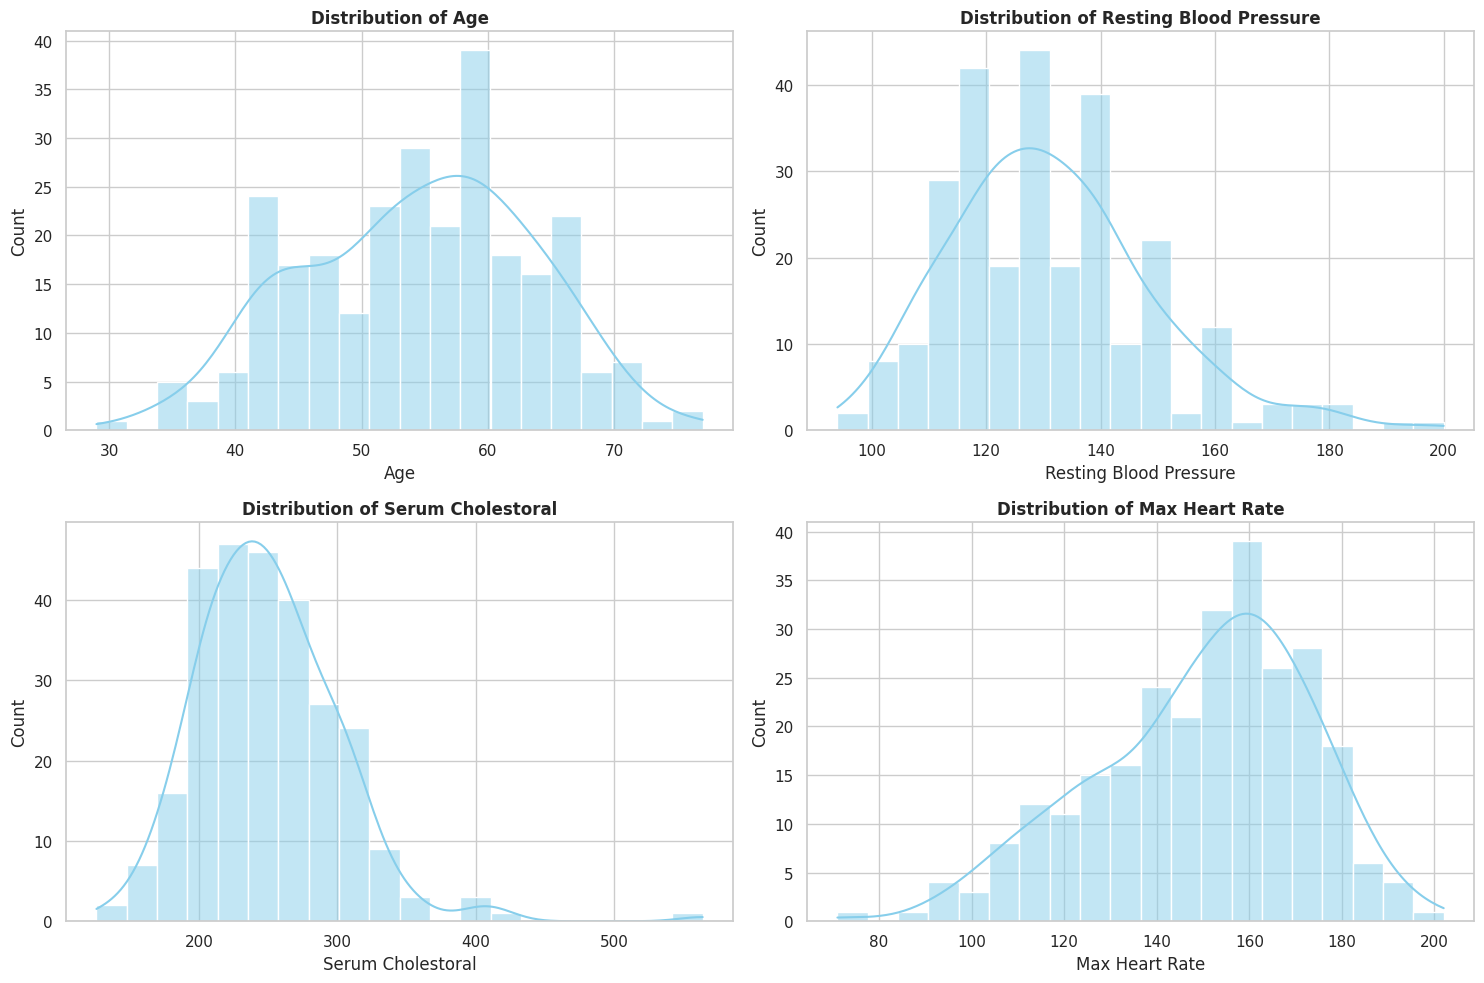

/tmp/ipykernel_9596/3785016740.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[target], palette=['#4CAF50', '#FF5252'])


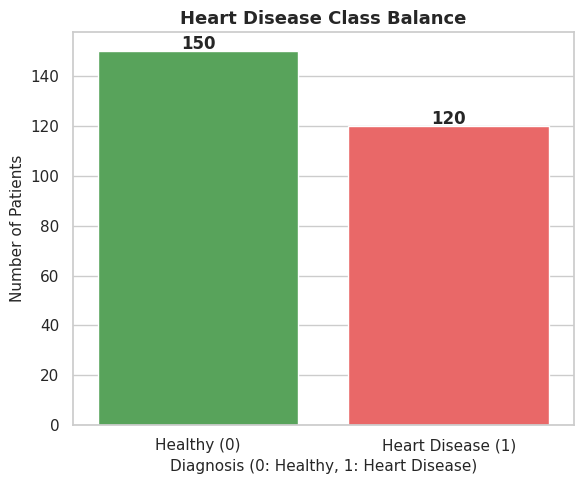

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style général des graphiques
sns.set_theme(style="whitegrid")

# =====================================================================
# TODO: pick a few numeric columns and plot histograms
# =====================================================================
# On sélectionne des variables numériques clés liées à la santé cardiaque
numeric_cols_to_plot = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols_to_plot, 1):
    plt.subplot(2, 2, i)
    # kde=True permet d'afficher la courbe de densité pour mieux voir la distribution
    sns.histplot(df[col], kde=True, color="skyblue", bins=20)
    plt.title(f'Distribution of {col.title()}', fontsize=12, fontweight='bold')
    plt.xlabel(col.title())
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# TODO: plot class balance as a bar chart
plt.figure(figsize=(6, 5))

# On compte le nombre d'occurrences pour chaque classe (0 = Sain, 1 = Malade)
# Note : Nous utilisons la variable 'target' que nous avons nettoyée précédemment ('heart_disease')
sns.countplot(x=df[target], palette=['#4CAF50', '#FF5252'])

plt.title('Heart Disease Class Balance', fontsize=13, fontweight='bold')
plt.xlabel('Diagnosis (0: Healthy, 1: Heart Disease)', fontsize=11)
plt.ylabel('Number of Patients', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Healthy (0)', 'Heart Disease (1)'])

# Ajouter les étiquettes de score au-dessus de chaque barre pour plus de clarté
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

## Preprocessing pipeline

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# TODO: identify categorical and numerical columns
# On extrait dynamiquement les colonnes selon leur type de données dans pandas
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Note : Si tu souhaites traiter certaines colonnes numériques (comme 'sex' ou 'chest pain type')
# comme des variables catégorielles brutes, tu peux manuellement les déplacer ainsi :
# columns_to_encode = ['sex', 'chest pain type', 'fasting blood sugar', 'resting electrocardiographic results', 'exercise induced angina', 'ST segment', 'thal']
# num_cols = [col for col in num_cols if col not in columns_to_encode]
# cat_cols = cat_cols + columns_to_encode

print(f"Colonnes numériques identifiées ({len(num_cols)}) : {num_cols}")
print(f"Colonnes catégorielles identifiées ({len(cat_cols)}) : {cat_cols}")

# TODO: build a ColumnTransformer named pre
# On crée des sous-pipelines pour gérer proprement l'imputation et la mise à l'échelle
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

pre = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("\n ColumnTransformer 'pre' configuré avec succès et prêt pour l'entraînement !")

Colonnes numériques identifiées (13) : ['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal']
Colonnes catégorielles identifiées (0) : []

 ColumnTransformer 'pre' configuré avec succès et prêt pour l'entraînement !


## Helper - evaluation function

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }

    # Affichage propre des métriques dans la console
    print(f"=== {name} Performance ===")
    for metric_name, val in metrics.items():
        print(f"{metric_name.capitalize():<10}: {val:.4f}")
    print("=" * (20 + len(name)))

    # Préparation de la figure graphique (1 ligne, 2 colonnes)
    has_proba = hasattr(model, "predict_proba")
    fig, axes = plt.subplots(1, 2 if has_proba else 1, figsize=(12 if has_proba else 6, 5))

    # Si un seul graphique est dessiné, on s'assure qu'axes soit manipulable comme une liste
    if not has_proba:
        axes = [axes]

    # TODO: confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Disease (1)'])
    disp.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title(f'Confusion Matrix - {name}')
    axes[0].grid(False)  # Désactive le quadrillage pour une meilleure lisibilité de la matrice

    # TODO: ROC curve if model has predict_proba
    if has_proba:
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)

        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Ligne de référence aléatoire
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
        axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)')
        axes[1].set_title(f'ROC Curve - {name}')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

=== Logistic Regression (Without GridSearch) Performance ===
Accuracy  : 0.8519
Precision : 0.7857
Recall    : 0.9167
F1        : 0.8462


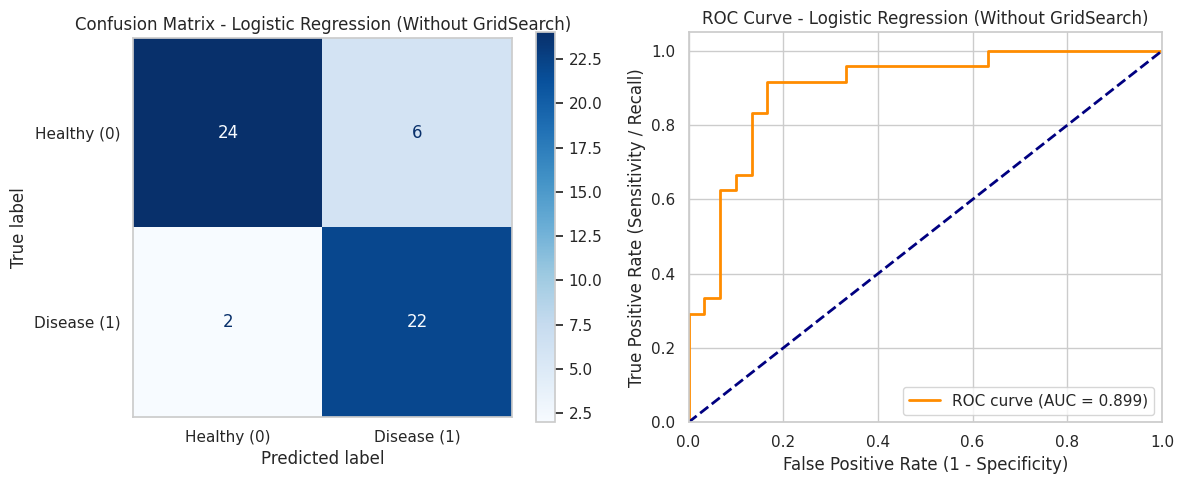

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline([
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report(
    name="Logistic Regression (Without GridSearch)",
    model=pipe_lr,
    X_test=X_test,
    y_test=y_test
)

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'classifier__C': 0.001, 'classifier__penalty': 'l2'}
=== LR grid Performance ===
Accuracy  : 0.8148
Precision : 0.7692
Recall    : 0.8333
F1        : 0.8000


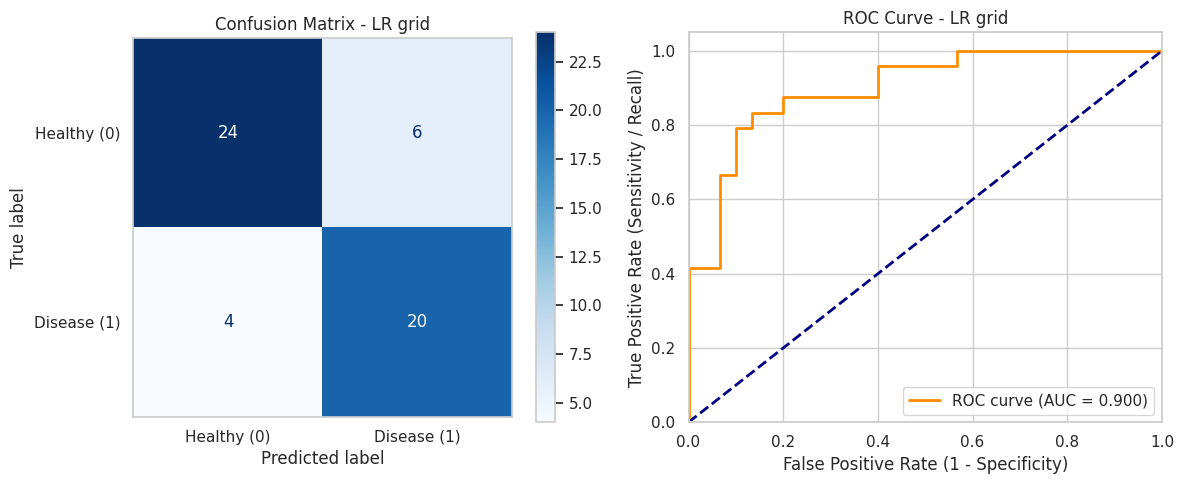

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline([
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))
])

# TODO: define param_grid for classifier__C and classifier__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(
    estimator=pipe_lr_cv,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Entraînement de la recherche par grille sur les données d'entraînement
grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)

# Récupération du meilleur modèle trouvé
best_lr = grid_lr.best_estimator_

# Évaluation du modèle optimisé avec la fonction de rapport
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

=== SVM no grid Performance ===
Accuracy  : 0.8148
Precision : 0.7692
Recall    : 0.8333
F1        : 0.8000


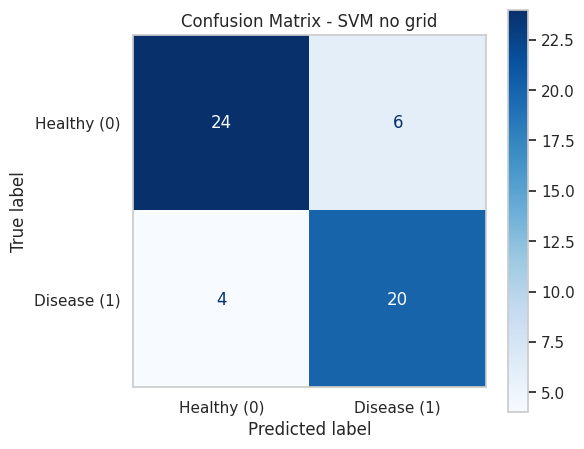

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline([
    ('preprocessor', pre),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# Entraînement du modèle sur les données d'entraînement
pipe_svm.fit(X_train, y_train)

# Évaluation du modèle de base avec la fonction de rapport
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

Best params: {'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
=== SVM grid Performance ===
Accuracy  : 0.8519
Precision : 0.8077
Recall    : 0.8750
F1        : 0.8400


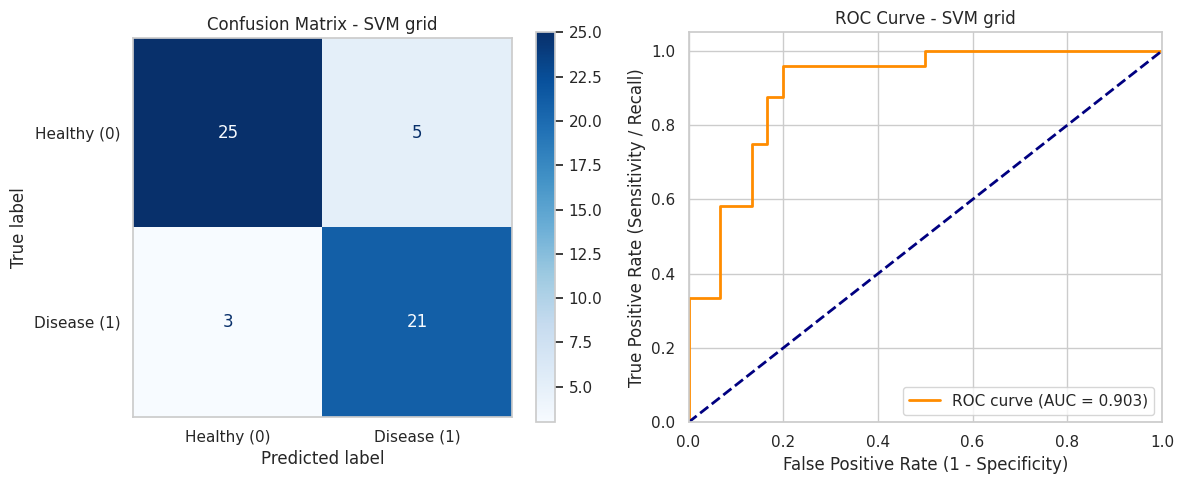

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('preprocessor', pre),
    ('classifier', SVC(probability=True, random_state=42))
])

# TODO: param_grid with classifier__kernel, classifier__C, classifier__gamma
svm_param_grid = {
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(
    estimator=pipe_svm_cv,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Entraînement de la recherche par grille
grid_svm.fit(X_train, y_train)

print('Best params:', grid_svm.best_params_)

# Récupération du meilleur estimateur
best_svm = grid_svm.best_estimator_

# Évaluation et génération des graphiques (Matrice de confusion + Courbe ROC)
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

=== XGB no grid Performance ===
Accuracy  : 0.7963
Precision : 0.7407
Recall    : 0.8333
F1        : 0.7843


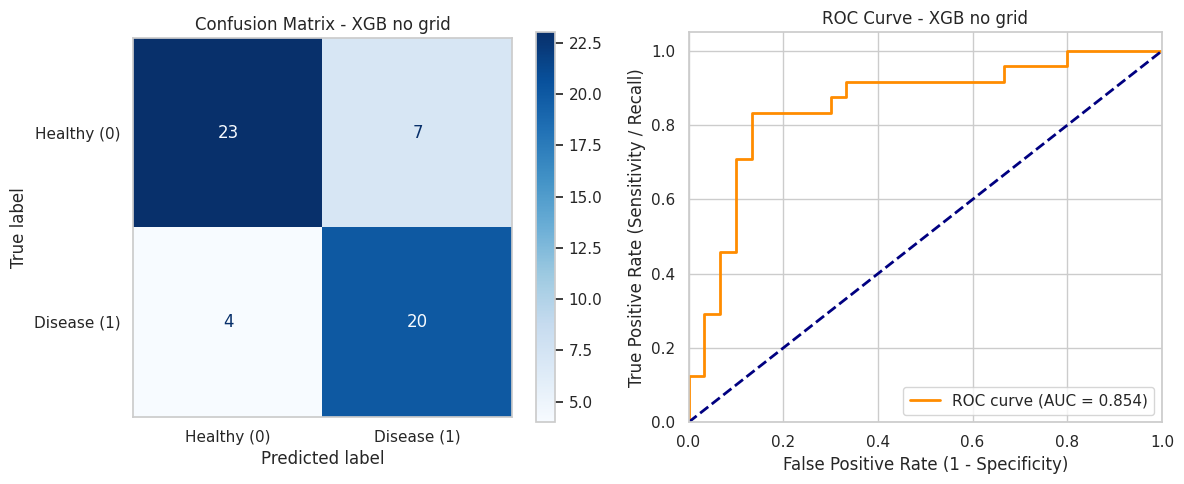

In [15]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline([
    ('preprocessor', pre),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric='logloss'  # Évite les avertissements de XGBoost lors du fit
    ))
])

# TODO: fit on training data
pipe_xgb.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)

## Exercise 7 - XGBoost with Grid Search

Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
=== XGB grid Performance ===
Accuracy  : 0.7963
Precision : 0.7407
Recall    : 0.8333
F1        : 0.7843


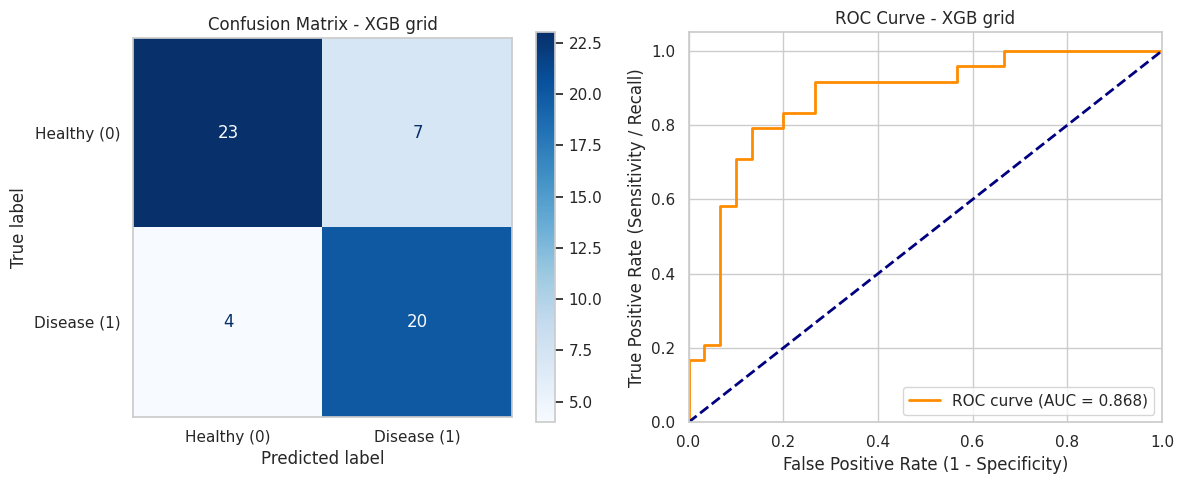

In [16]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([
    ('preprocessor', pre),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 4, 5],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(
    estimator=pipe_xgb_cv,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Entraînement de la recherche par grille
grid_xgb.fit(X_train, y_train)

print('Best params:', grid_xgb.best_params_)

# Récupération du meilleur estimateur
best_xgb = grid_xgb.best_estimator_

# Évaluation finale avec graphiques automatiques (Matrice de confusion + Courbe ROC)
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)

## Compare models

In [17]:
import pandas as pd

# TODO: build a comparison DataFrame from your metrics dicts
summary = {}

# Ajout des métriques de la Régression Logistique
if 'lr_no_gs_metrics' in globals() and lr_no_gs_metrics is not None:
    summary['LR (No Grid)'] = lr_no_gs_metrics
if 'lr_gs_metrics' in globals() and lr_gs_metrics is not None:
    summary['LR (GridSearch)'] = lr_gs_metrics

# Ajout des métriques du SVM
if 'svm_no_metrics' in globals() and svm_no_metrics is not None:
    summary['SVM (No Grid)'] = svm_no_metrics
if 'svm_gs_metrics' in globals() and svm_gs_metrics is not None:
    summary['SVM (GridSearch)'] = svm_gs_metrics

# Ajout des métriques de XGBoost
if 'xgb_no_metrics' in globals() and xgb_no_metrics is not None:
    summary['XGBoost (No Grid)'] = xgb_no_metrics
if 'xgb_gs_metrics' in globals() and xgb_gs_metrics is not None:
    summary['XGBoost (GridSearch)'] = xgb_gs_metrics

# Conversion du dictionnaire en DataFrame (orientation 'index' pour avoir les modèles en lignes)
df_summary = pd.DataFrame.from_dict(summary, orient='index')

# Tri du tableau par le score F1 (métrique clé pour ce problème médical)
df_summary = df_summary.sort_values(by='f1', ascending=False)

# Affichage du tableau comparatif
print("=== Tableau Comparatif des Modèles ===")
print(df_summary.round(4))  # Arrondi à 4 décimales pour plus de clarté

=== Tableau Comparatif des Modèles ===
                      accuracy  precision  recall      f1
LR (No Grid)            0.8519     0.7857  0.9167  0.8462
SVM (GridSearch)        0.8519     0.8077  0.8750  0.8400
LR (GridSearch)         0.8148     0.7692  0.8333  0.8000
SVM (No Grid)           0.8148     0.7692  0.8333  0.8000
XGBoost (No Grid)       0.7963     0.7407  0.8333  0.7843
XGBoost (GridSearch)    0.7963     0.7407  0.8333  0.7843
